# This file is used to do analysis for NO CV experiments


In [3]:
import pandas as pd
import numpy as np
import os
import sys
from sklearn.metrics import mean_squared_error
import json
from matplotlib import pyplot as plt

In [4]:
DATASET_MAX_N_OBS = {
    'autompg': 400,
    'breastcancer': 200,
    'fertility': 100,  # Small dataset
    'forest': 500,
    'housing': 500,
    'pendulum': 500,
    'qsar_aquatic_toxicity': 500,
    'servo': 100,      # Small dataset
    'stock': 500,
    'yacht_hydrodynamics': 300 , # Medium dataset
    'ENB2012_data_energy_heating': 768,
    'ENB2012_data_energy_cooling': 768,
    'real_estate': 414,
    'winequality-red': 1599,
    'winequality-white': 4898,
    'airfoil_self_noise': 1503,
    'qsar_fish_toxicity': 908,
    'Combined_Cycle_Power_Plant': 9568,
}

def get_valid_n_obs_list(data_name, requested_n_obs_list):
    """
    Filter n_obs_list based on dataset's maximum available samples
    
    Args:
        data_name: Name of the dataset
        requested_n_obs_list: List of requested sample sizes
        
    Returns:
        Filtered list of valid sample sizes
    """
    max_n_obs = DATASET_MAX_N_OBS.get(data_name, 500)
    valid_list = [n for n in requested_n_obs_list if n <= max_n_obs]
    
    return valid_list

# List of datasets (same as in experiment)
data_names = [
    'fertility', 
    'forest',
    'qsar_aquatic_toxicity', 
    'stock', 
    'yacht_hydrodynamics',
    'real_estate',
    'winequality-red',
    'winequality-white',
    'qsar_fish_toxicity',
    'Combined_Cycle_Power_Plant'
]


In [52]:
def calculate_mse_metrics(data_name, n_obs_list_full = [50,100,200,300,400,500], 
                            results_dir='../results', metrics_dir='./metrics'):
    """
    Calculate MSE for all models across different sample sizes and replications
    
    Args:
        data_name: Dataset name (e.g., 'autompg')
        n_obs_list: List of sample sizes to analyze
        save: Whether to save results to CSV
        results_dir: Directory containing experiment results
        metrics_dir: Directory to save metrics (if None, won't save even if save=True)
    
    Returns:
        DataFrame with columns: data, n_obs, r, base_rf, rf10, rf100, srf_normal_*, srf_hypsec_*
    """
    n_obs_list = get_valid_n_obs_list(data_name, n_obs_list_full)
    # List to store results
    results_list = []
    
    # Define all model names (use original names for reading)
    baseline_model_names = ['rf10', 'rf20', 'rf50', 'rf_100','gp']
    srf_model_names = ['srf_normal_EST_PD','srf_hypsec_EST_PD']
    
    # Iterate through all sample sizes and replications
    for n_obs in n_obs_list:
        for r in range(100):  # 100 replications
            baseline_pred_file = f'{results_dir}/{data_name}/predictions/{data_name}_n{n_obs}_r{r}.csv'
            srf_pred_file = f'{results_dir}/{data_name}/EST_PD_predictions_noCV/{data_name}_n{n_obs}_r{r}.csv'
            
            # Check if file exists
            if not os.path.exists(baseline_pred_file):
                continue
            
            try:
                # Load predictions
                baseline_pred_df = pd.read_csv(baseline_pred_file)
                srf_pred_df = pd.read_csv(srf_pred_file)
                y_test = baseline_pred_df['y_test'].values
                
                # Create result dictionary for this replication
                result = {
                    'data': data_name,
                    'n_obs': n_obs,
                    'r': r
                }
                
                # Calculate MSE for each model
                for model in baseline_model_names:
                    pred_col = f'{model}_pred'
                    
                    if pred_col in baseline_pred_df.columns:
                        y_pred = baseline_pred_df[pred_col].values
                        
                        # Check for NaN values
                        if np.any(np.isnan(y_pred)):
                            result[model] = np.nan
                        else:
                            result[model] = mean_squared_error(y_test, y_pred)
                    else:
                        result[model] = np.nan
                for srf_model in srf_model_names:
                    pred_col = f'{srf_model}_pred'
                    
                    if pred_col in srf_pred_df.columns:
                        y_pred = srf_pred_df[pred_col].values
                        
                        # Check for NaN values
                        if np.any(np.isnan(y_pred)):
                            result[srf_model] = np.nan
                        else:
                            result[srf_model] = mean_squared_error(y_test, y_pred)
                    else:
                        result[srf_model] = np.nan
                        
                
                results_list.append(result)
                
            except Exception as e:
                print(f"Error processing {data_name} n={n_obs} r={r}: {e}")
                continue
    
    # Create DataFrame
    results_df = pd.DataFrame(results_list)
    
    # Rename rf_full to rf100
    model_names_display = [m if m != 'rf_100' else 'rf100' for m in baseline_model_names]
    # combine srf_normal_EST_PD and srf_hypsec_EST_PD into baseline_model_names
    results_df.rename(columns={'rf_100': 'rf100'}, inplace=True)
    model_names_display.append('srf_normal_EST_PD')
    model_names_display.append('srf_hypsec_EST_PD')
    # Reorder columns
    cols_order = ['data', 'n_obs', 'r'] + model_names_display
    results_df = results_df[cols_order]
    results_df.rename(columns={
        'data':'Data',
        'rf10':'RF(10)',
        'rf20':'RF(20)',
        'rf50':'RF(50)',
        'rf100': 'RF(100)',
        'gp':'GP',
        'srf_normal_EST_PD':'EST-PD(Norm)',
        'srf_hypsec_EST_PD':'EST-PD(Hypsec)'}, inplace=True)
    
    # Save if requested and metrics_dir is not None
    if metrics_dir is not None:
        save_path = f'{metrics_dir}/{data_name}/{data_name}_mse.csv'
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        results_df.to_csv(save_path, index=False)
        print(f"Saved metrics to: {save_path}")
    
    else:
        return results_df

In [53]:
for data in data_names:
    calculate_mse_metrics(data_name=data,metrics_dir= './metrics')

Saved metrics to: ./metrics/fertility/fertility_mse.csv
Saved metrics to: ./metrics/forest/forest_mse.csv
Saved metrics to: ./metrics/qsar_aquatic_toxicity/qsar_aquatic_toxicity_mse.csv
Saved metrics to: ./metrics/stock/stock_mse.csv
Saved metrics to: ./metrics/yacht_hydrodynamics/yacht_hydrodynamics_mse.csv
Saved metrics to: ./metrics/real_estate/real_estate_mse.csv
Saved metrics to: ./metrics/winequality-red/winequality-red_mse.csv
Saved metrics to: ./metrics/winequality-white/winequality-white_mse.csv
Saved metrics to: ./metrics/qsar_fish_toxicity/qsar_fish_toxicity_mse.csv
Saved metrics to: ./metrics/Combined_Cycle_Power_Plant/Combined_Cycle_Power_Plant_mse.csv


In [54]:
def combine_all_data_metrics(metric,data_list,metrics_path,save_path=None):
    metric_df = pd.DataFrame()
    for data_name in data_list:
        metric_df = pd.concat([metric_df,pd.read_csv(f'{metrics_path}/{data_name}/{data_name}_{metric}.csv')])

    if save_path is not None:
        metric_df.to_csv(f'{save_path}/{metric}_combined_all_data.csv',index=False)
    else:
        return metric_df

In [55]:
combine_all_data_metrics(metric='mse',data_list=data_names,
                                        metrics_path= './metrics',
                                        save_path= './metrics')

In [56]:
combined_mse = pd.read_csv('./metrics/mse_combined_all_data.csv')

# Get Percentage Improvement over RF(10)

In [57]:
def calculate_percentage(df):
    pi_df = pd.DataFrame()
    pi_df['Data'] = df['Data']
    pi_df['N'] = df['N']
    pi_df['P'] = df['P']
    pi_df['n'] = df['n']
    pi_df['r'] = df['r']
    
    pi_df['RF(20)'] = round((df['RF(10)'] - df['RF(20)'])/df['RF(10)']*100,4)
    pi_df['RF(50)'] = round((df['RF(10)'] - df['RF(50)'])/df['RF(10)']*100,4)
    pi_df['RF(100)'] = round((df['RF(10)'] - df['RF(100)'])/df['RF(10)']*100,4)
    pi_df['GP'] = round((df['RF(10)'] - df['GP'])/df['RF(10)']*100,4)

    pi_df['EST-PD(Norm)'] = round((df['RF(10)'] - df['EST-PD(Norm)'])/df['RF(10)']*100,4)
    pi_df['EST-PD(Hypsec)'] = round((df['RF(10)'] - df['EST-PD(Hypsec)'])/df['RF(10)']*100,4)

    return pi_df

In [58]:
def add_data_info(data_names):
    data_info = pd.DataFrame()
    p_list = []
    n_list = []
    for data_name in data_names:
        data = pd.read_csv(f'../../data/{data_name}.csv')
        p_list.append(data.shape[1]-1)
        n_list.append(data.shape[0])
    data_info['Data'] = data_names
    data_info['P'] = p_list
    data_info['N'] = n_list
    return data_info

In [59]:
data_info = add_data_info(data_names)

In [60]:
# combine data_info with best_model_pi
combined_mse_df = pd.merge(combined_mse, data_info, on='Data', how='left')
# rename n to n_obs
combined_mse_df = combined_mse_df.rename(columns={'n_obs':'n'})
# order the columns
combined_mse_df = combined_mse_df[['Data','N','P','n','r','RF(10)','RF(20)','RF(50)','RF(100)','GP','EST-PD(Norm)','EST-PD(Hypsec)']]

In [61]:
data_name_mapping = {
    'Combined_Cycle_Power_Plant': 'CCPP',
    'qsar_fish_toxicity': 'Qsar Fish Toxicity',
    'real_estate': 'Real Estate',
    'yacht_hydrodynamics': 'Yacht Hydrodynamics',
    'qsar_aquatic_toxicity': 'Qsar Aquatic Toxicity',
    'fertility': 'Fertility',
    'stock': 'Stock',
    'winequality-red': 'Winequality (Red)',
    'winequality-white': 'Winequality (White)',
    'forest': 'Forest'
}
combined_mse_df['Data'] = combined_mse_df['Data'].replace(data_name_mapping)

In [62]:
pi_df = calculate_percentage(combined_mse_df)

In [63]:
pi_df.to_csv('./metrics/combined_PI.csv',index=False)

In [64]:
pi_df = pd.read_csv('./metrics/combined_PI.csv')

In [87]:
PIMSE_mean = pi_df.groupby(['Data','N','P']).mean().drop(columns=['r','n']).reset_index()
PIMSE_std = pi_df.groupby(['Data','N','P']).std().drop(columns=['r','n']).reset_index()
pi_df['cases'] = 1
cased_by_n_obs = pi_df.groupby(['Data']).sum().reset_index()
PIMSE_std['cases'] = cased_by_n_obs['cases']
mean_mse_95CI = pd.DataFrame()
mean_mse_95CI['Data'] = PIMSE_mean['Data']
mean_mse_95CI['N'] = PIMSE_mean['N']
mean_mse_95CI['P'] = PIMSE_mean['P']

mean_mse_95CI['RF(20)'] = [f"{m:.2f} ({s:.2f})" for m, s in zip(PIMSE_mean['RF(20)'], PIMSE_std['RF(20)']/np.sqrt(PIMSE_std['cases']))]
mean_mse_95CI['RF(50)'] = [f"{m:.2f} ({s:.2f})" for m, s in zip(PIMSE_mean['RF(50)'], PIMSE_std['RF(50)']/np.sqrt(PIMSE_std['cases']))]
mean_mse_95CI['RF(100)'] = [f"{m:.2f} ({s:.2f})" for m, s in zip(PIMSE_mean['RF(100)'], PIMSE_std['RF(100)']/np.sqrt(PIMSE_std['cases']))]
mean_mse_95CI['GP'] = [f"{m:.2f} ({s:.2f})" for m, s in zip(PIMSE_mean['GP'], PIMSE_std['GP']/np.sqrt(PIMSE_std['cases']))]
mean_mse_95CI['EST-PD(Norm)'] = [f"{m:.2f} ({s:.2f})" for m, s in zip(PIMSE_mean['EST-PD(Norm)'], PIMSE_std['EST-PD(Norm)']/np.sqrt(PIMSE_std['cases']))]
mean_mse_95CI['EST-PD(Hypsec)'] = [f"{m:.2f} ({s:.2f})" for m, s in zip(PIMSE_mean['EST-PD(Hypsec)'], PIMSE_std['EST-PD(Hypsec)']/np.sqrt(PIMSE_std['cases']))]

mean_best_model_pi = mean_mse_95CI.sort_values(by='P', ascending=True)

In [88]:
mean_best_model_pi

,Data,N,P,RF(20),RF(50),RF(100),GP,EST-PD(Norm),EST-PD(Hypsec)
0,CCPP,9568,4,4.40 (0.16),6.89 (0.18),7.62 (0.19),-76.48 (4.10),12.39 (0.15),12.88 (0.16)
4,Qsar Fish Toxicity,908,6,3.47 (0.14),5.62 (0.17),6.25 (0.17),-19.49 (0.73),8.04 (0.18),8.00 (0.18)
5,Real Estate,414,6,3.69 (0.27),6.17 (0.33),6.83 (0.34),-100.77 (1.75),2.99 (0.42),3.22 (0.42)
9,Yacht Hydrodynamics,308,6,16.29 (1.38),29.94 (1.27),33.22 (1.21),-284.56 (14.84),26.60 (0.90),26.05 (0.91)
3,Qsar Aquatic Toxicity,537,8,4.27 (0.18),6.28 (0.21),6.94 (0.22),-47.49 (1.41),6.72 (0.20),6.65 (0.20)
1,Fertility,100,9,0.91 (0.51),2.38 (0.64),3.19 (0.62),-1.24 (1.34),12.94 (0.72),13.08 (0.73)
6,Stock,536,11,8.48 (0.22),11.20 (0.25),12.03 (0.25),-422.89 (5.17),16.22 (0.30),16.14 (0.30)
7,Winequality (Red),1599,11,3.75 (0.11),5.78 (0.15),6.51 (0.16),-24.66 (0.39),7.49 (0.19),7.54 (0.19)
8,Winequality (White),4898,11,3.98 (0.10),6.32 (0.12),7.11 (0.13),-17.85 (0.36),7.23 (0.16),7.19 (0.16)
2,Forest,517,12,2.96 (0.16),4.81 (0.18),5.51 (0.18),18.98 (0.28),15.59 (0.21),15.45 (0.21)


In [86]:
mean_best_model_pi.to_csv('./metrics/mean_PI_paper_table.csv',index=False)

In [5]:
pi_df = pd.read_csv('./metrics/combined_PI.csv')

In [5]:
pi_df

,Data,N,P,n,r,RF(20),RF(50),RF(100),GP,EST-PD(Norm),EST-PD(Hypsec)
0,Fertility,100,9,50,0,-1.0494,-3.0970,2.3248,14.0984,20.7553,20.7815
1,Fertility,100,9,50,1,9.4287,12.5960,10.5270,-6.2826,10.0622,10.6005
2,Fertility,100,9,50,2,4.4689,1.0398,4.3473,-11.1183,11.2289,10.8808
3,Fertility,100,9,50,3,-7.6097,0.0202,0.0534,0.5117,8.3785,8.7366
4,Fertility,100,9,50,4,7.3313,9.3448,10.0583,7.1815,12.5709,13.5310
...,...,...,...,...,...,...,...,...,...,...,...
5295,CCPP,9568,4,500,95,3.2629,7.3455,8.1882,-77.6549,13.0288,13.9890
5296,CCPP,9568,4,500,96,1.5240,5.6642,6.3279,-78.2748,12.5555,12.3855
5297,CCPP,9568,4,500,97,2.7722,5.7735,7.0081,-56.6098,10.0124,10.7027
5298,CCPP,9568,4,500,98,3.3145,5.2921,5.6074,-91.9382,7.6035,7.9334


In [70]:
stats_df = pi_df.drop(columns=['Data','N','n','P','r'])

In [71]:
stats_df

,RF(20),RF(50),RF(100),GP,EST-PD(Norm),EST-PD(Hypsec)
0,-1.0494,-3.0970,2.3248,14.0984,20.7553,20.7815
1,9.4287,12.5960,10.5270,-6.2826,10.0622,10.6005
2,4.4689,1.0398,4.3473,-11.1183,11.2289,10.8808
3,-7.6097,0.0202,0.0534,0.5117,8.3785,8.7366
4,7.3313,9.3448,10.0583,7.1815,12.5709,13.5310
...,...,...,...,...,...,...
5295,3.2629,7.3455,8.1882,-77.6549,13.0288,13.9890
5296,1.5240,5.6642,6.3279,-78.2748,12.5555,12.3855
5297,2.7722,5.7735,7.0081,-56.6098,10.0124,10.7027
5298,3.3145,5.2921,5.6074,-91.9382,7.6035,7.9334


In [6]:
from autorank import autorank, plot_stats, create_report, latex_table

In [73]:
result = autorank(stats_df, alpha=0.05, verbose=True, order='descending')

/opt/homebrew/Caskroom/miniforge/base/envs/my_research_env/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5300.
  res = hypotest_fun_out(*samples, **kwds)


Rejecting null hypothesis that data is normal for column RF(20) (p=0.000000<0.008333)
Rejecting null hypothesis that data is normal for column RF(50) (p=0.000000<0.008333)
Rejecting null hypothesis that data is normal for column RF(100) (p=0.000000<0.008333)
Rejecting null hypothesis that data is normal for column GP (p=0.000000<0.008333)
Rejecting null hypothesis that data is normal for column EST-PD(Norm) (p=0.000000<0.008333)
Rejecting null hypothesis that data is normal for column EST-PD(Hypsec) (p=0.000000<0.008333)
Using Levene's test for homoscedacity of non-normal data.
Rejecting null hypothesis that all variances are equal (p=0.000000<0.050000)
Using Friedman test as omnibus test
Rejecting null hypothesis that there is no difference between the distributions (p=0.000000)
Using Nemenyi post-hoc test. Differences are significant,if the distance between the mean ranks is greater than the critical distance.
                meanrank    median      mad ci_lower ci_upper effect_size 

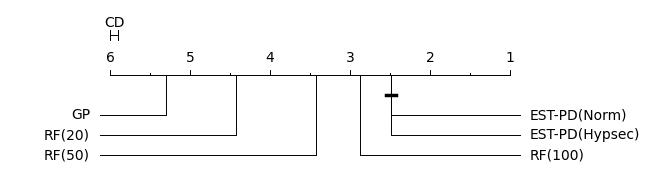

In [74]:
plot_stats(result)
plt.savefig('./figures/critical_difference_autorank.pdf', 
           dpi=300, bbox_inches='tight')

In [77]:
latex = latex_table(result)

\begin{table}[h]
\centering
\begin{tabular}{lrrllll}
\toprule
 & MR & MED & MAD & CI & $\gamma$ & Magnitude \\
\midrule
GP & 5.302 & -31.137 & 37.086 & [-34.277, -28.277] & 0.000 & negligible \\
RF(20) & 4.424 & 4.239 & 2.581 & [4.017, 4.487] & -0.908 & large \\
RF(50) & 3.420 & 6.631 & 3.071 & [6.343, 6.896] & -0.968 & large \\
RF(100) & 2.879 & 7.319 & 3.198 & [7.047, 7.598] & -0.985 & large \\
EST-PD(Hypsec) & 2.493 & 9.985 & 4.527 & [9.629, 10.461] & -1.050 & large \\
EST-PD(Norm) & 2.482 & 9.963 & 4.482 & [9.579, 10.409] & -1.049 & large \\
\bottomrule
\end{tabular}
\caption{Summary of populations}
\label{tbl:stat_results}
\end{table}


In [78]:
report = create_report(result)

The statistical analysis was conducted for 6 populations with 5300 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations GP (p=0.000), RF(20) (p=0.000), RF(50) (p=0.000), RF(100) (p=0.000), EST-PD(Hypsec) (p=0.000), and EST-PD(Norm) (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.104 of th

In [6]:
pi_df = pd.read_csv('./metrics/combined_PI.csv')

In [7]:
pi_df

,Data,N,P,n,r,RF(20),RF(50),RF(100),GP,EST-PD(Norm),EST-PD(Hypsec)
0,Fertility,100,9,50,0,-1.0494,-3.0970,2.3248,14.0984,20.7553,20.7815
1,Fertility,100,9,50,1,9.4287,12.5960,10.5270,-6.2826,10.0622,10.6005
2,Fertility,100,9,50,2,4.4689,1.0398,4.3473,-11.1183,11.2289,10.8808
3,Fertility,100,9,50,3,-7.6097,0.0202,0.0534,0.5117,8.3785,8.7366
4,Fertility,100,9,50,4,7.3313,9.3448,10.0583,7.1815,12.5709,13.5310
...,...,...,...,...,...,...,...,...,...,...,...
5295,CCPP,9568,4,500,95,3.2629,7.3455,8.1882,-77.6549,13.0288,13.9890
5296,CCPP,9568,4,500,96,1.5240,5.6642,6.3279,-78.2748,12.5555,12.3855
5297,CCPP,9568,4,500,97,2.7722,5.7735,7.0081,-56.6098,10.0124,10.7027
5298,CCPP,9568,4,500,98,3.3145,5.2921,5.6074,-91.9382,7.6035,7.9334


In [8]:
from matplotlib.ticker import MultipleLocator

def label_mapping_func(com_name):
    pir_name = r'$PI_{MSE}$'
    return f'{pir_name}({com_name})'


def plot_metric_percentage_improve(result_df,
                                   ncol=5,
                                plot_type='line',
                                figure_size = (20,13),
                                show_legend=False,
                                save_path=None):

    data_list = ['CCPP',
                'Qsar Fish Toxicity',
                'Real Estate',
                'Yacht Hydrodynamics',
                'Qsar Aquatic Toxicity',
                'Fertility',
                'Stock',
                'Winequality (Red)',
                'Winequality (White)',
                'Forest']
    #data_list = metric_df['data'].unique().tolist()
    rows = len(data_list)//ncol
    models = {'RF(20)':'RF(20)',
              'RF(50)':'RF(50)',
              'RF(100)':'RF(100)',
              #'GP':'GP',
              'EST-PD(Norm)':'EST-PD(Norm)',
              'EST-PD(Hypsec)':'EST-PD(Hypsec)'}
    
    srf_models = ['SRF_EST_PD(Norm)','SRF_EST_PD(Hypsec)']
    cmap = plt.get_cmap("tab10")

    color_mapping = {
            'RF(20)':cmap(0), 
            'RF(50)':cmap(1),
            'RF(100)':cmap(2),
            'GP':cmap(3),
            'EST-PD(Norm)':cmap(4),
            'EST-PD(Hypsec)':cmap(5)
        }

    if len(data_list)%ncol != 0:
        rows += 1
    fig,axes = plt.subplots(rows,ncol,figsize=figure_size,sharex=False,sharey=False,)
    
    for i,data in enumerate(data_list):
        data_name = data
        data_df = result_df[result_df['Data']==data]
        q_list = data_df['n'].unique().tolist()

        q_list_strings = list(map(str, q_list)) 
        # if q_list[1] == 20 and len(q_list) > 4:
        #     q_list_strings[1] = ''
        n_obs = data_df['N'].unique()[0]
        dim = data_df['P'].unique()[0]
        # print("q_list:", q_list)
        for model in models:
            model_name = models[model]
            mean_list = data_df[[model,'n','r']].groupby('n').mean()[model].values.tolist()
            std_list = data_df[[model,'n','r']].groupby('n').std()[model].values.tolist()
            # get 95% confidence interval
            std_list = [1.96*std/np.sqrt(100) for std in std_list]
            #mean_list = [mean*100 for mean in mean_list]
            if plot_type == 'line':
                axes[i//ncol,i%ncol].plot(q_list,mean_list,label=label_mapping_func(model_name),marker='.',color = color_mapping[model])
            elif plot_type == 'errorbar':
                eb = axes[i//ncol,i%ncol].errorbar(q_list,mean_list,yerr=std_list,
                                              label=label_mapping_func(model_name),
                                              color = color_mapping[model],
                                              linewidth=3,
                                              capsize=5,
                                              linestyle='-' if model in srf_models else '--')
                eb[-1][0].set_linestyle((0, (1, 1)))
            
        # axes[i//ncol,i%ncol].set_title(r"{} ($\mathit{{n={}}}$, $\mathit{{p={}}}$)".format(data.capitalize(), n_obs, dim), fontsize = 20)
        axes[i//ncol,i%ncol].set_title(data_name, fontsize = 26)
        #axes[i//ncol,i%ncol].set_xlabel('Training Size',fontsize = 15)
        # set xticks fontsize
        axes[i//ncol,i%ncol].tick_params(axis='x', labelsize=22)
        axes[i//ncol,i%ncol].tick_params(axis='y', labelsize=22)

        ##########################
        ##### Added by Felix #####
        axes[i//ncol,i%ncol].set_xticks(q_list)
        axes[i//ncol,i%ncol].set_xticklabels(q_list_strings)
        axes[i//ncol,i%ncol].xaxis.set_tick_params(rotation=60) 
        ##########################
        # if i//ncol ==0:
        #     axes[i//ncol,i%ncol].set_yscale('symlog',linthresh=0.15)
        # else:  
        #     axes[i//ncol,i%ncol].set_yscale('symlog',linthresh=0.15)
        axes[i//ncol,i%ncol].grid()
        
        # add a horizontal line at 0
        axes[i//ncol,i%ncol].axhline(0, color='grey', linestyle='--')
    #axes[i//ncol,i%ncol].set_yscale('symlog',linthresh=0.2)


    # axes[0,0].set_yscale('symlog', linthresh=0.01)
    # axes[1,0].set_yscale('symlog', linthresh=0.01)

        
    if show_legend:
     
        handles, labels = axes[0,0].get_legend_handles_labels()
    
        fig.legend(handles, labels, loc='upper center', fontsize=22, ncol=6,
              bbox_to_anchor=(0.5, 1.09)) 
        ##########################
    #all suplots use one y label
    fig.text(-0.01,0.5,'MSE Percentage Improvement',va = 'center',rotation='vertical',fontsize = 30, fontweight='bold')
    fig.text(0.5,-0.02,'Training Size',ha = 'center',fontsize = 28, fontweight='bold')
    plt.subplots_adjust(wspace=0.05)
    plt.tight_layout()
    # save the figure with high dpi
    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight',dpi=300, format='pdf')

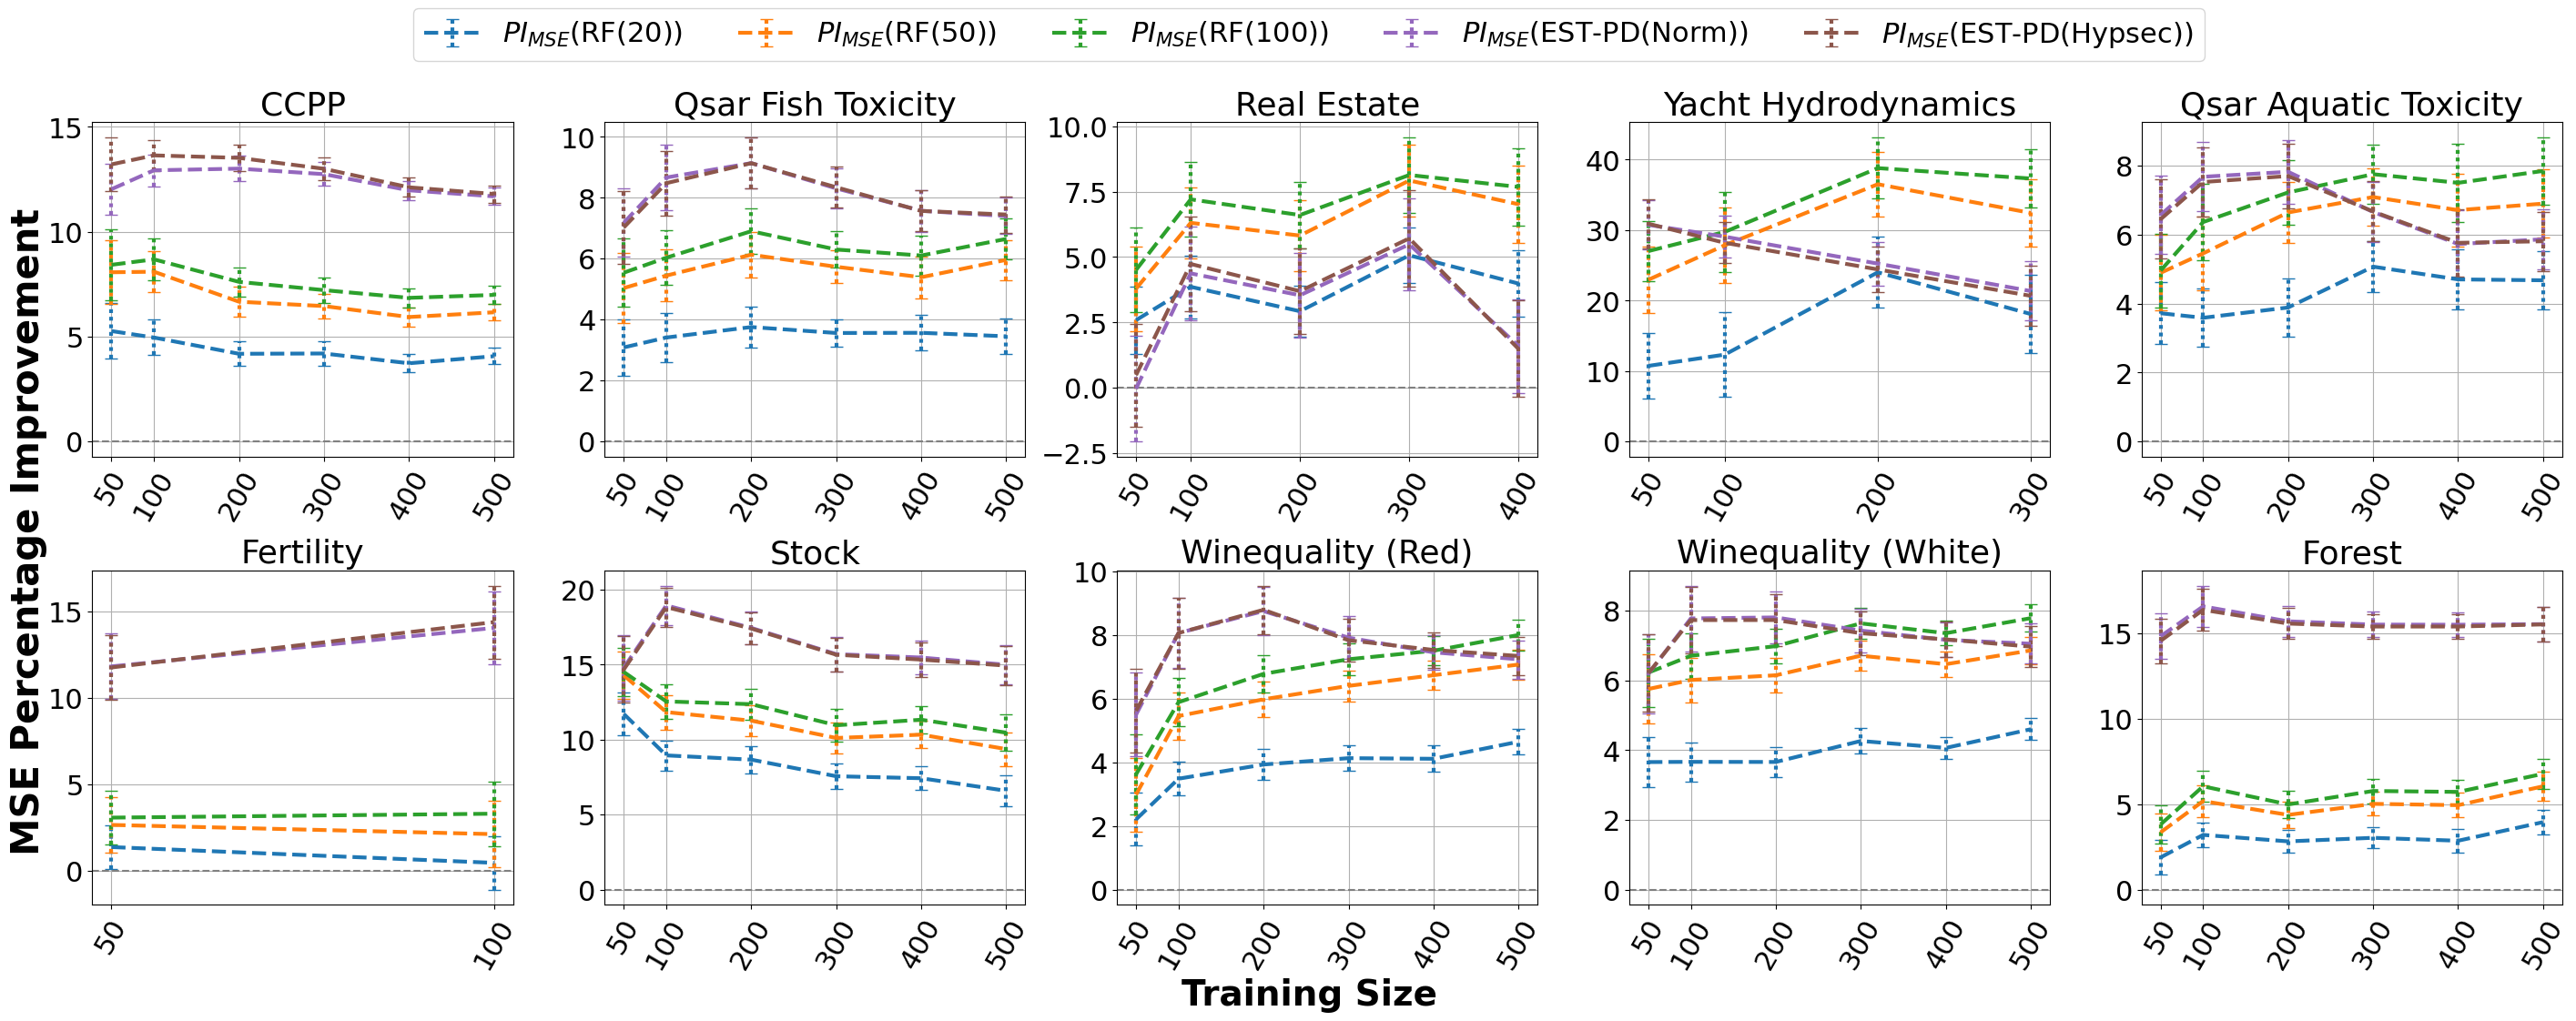

In [9]:
plot_metric_percentage_improve(result_df=pi_df,
                               ncol=5,
                               show_legend = True,
                               figure_size = (28,10),
                               plot_type = 'errorbar',
                               save_path = './figures/best_model_pi.pdf' )#'./figures/best_model_pi.pdf')

In [ ]:
from matplotlib.ticker import MultipleLocator

def label_mapping_func(com_name):
    pir_name = r'$PI_{MSE}$'
    return f'{pir_name}({com_name})'


def plot_metric_percentage_improve(result_df,
                                   ncol=4,
                                   plot_type='line',
                                   figure_size=(20, 15),
                                   show_legend=True,
                                   save_path=None):

    data_list = ['CCPP',
                'Qsar Fish Toxicity',
                'Real Estate',
                'Yacht Hydrodynamics',
                'Qsar Aquatic Toxicity',
                'Fertility',
                'Stock',
                'Winequality (Red)',
                'Winequality (White)',
                'Forest']

    rows = len(data_list) // ncol
    if len(data_list) % ncol != 0:
        rows += 1  # rows = 3 (4+4+2)

    models = {'RF(20)': 'RF(20)',
              'RF(50)': 'RF(50)',
              'RF(100)': 'RF(100)',
              'EST-PD(Norm)': 'EST-PD(Norm)',
              'EST-PD(Hypsec)': 'EST-PD(Hypsec)'}

    srf_models = ['SRF_EST_PD(Norm)', 'SRF_EST_PD(Hypsec)']
    cmap = plt.get_cmap("tab10")

    color_mapping = {
        'RF(20)': cmap(0),
        'RF(50)': cmap(1),
        'RF(100)': cmap(2),
        'GP': cmap(3),
        'EST-PD(Norm)': cmap(4),
        'EST-PD(Hypsec)': cmap(5)
    }

    fig, axes = plt.subplots(rows, ncol, figsize=figure_size,
                             sharex=False, sharey=False)

    for i, data in enumerate(data_list):
        data_name = data
        data_df = result_df[result_df['Data'] == data]
        q_list = data_df['n'].unique().tolist()
        q_list_strings = list(map(str, q_list))
        n_obs = data_df['N'].unique()[0]
        dim = data_df['P'].unique()[0]

        for model in models:
            model_name = models[model]
            mean_list = data_df[[model, 'n', 'r']].groupby('n').mean()[model].values.tolist()
            std_list = data_df[[model, 'n', 'r']].groupby('n').std()[model].values.tolist()
            std_list = [1.96 * std / np.sqrt(100) for std in std_list]

            if plot_type == 'line':
                axes[i // ncol, i % ncol].plot(
                    q_list, mean_list,
                    label=label_mapping_func(model_name),
                    marker='.', color=color_mapping[model]
                )
            elif plot_type == 'errorbar':
                eb = axes[i // ncol, i % ncol].errorbar(
                    q_list, mean_list, yerr=std_list,
                    label=label_mapping_func(model_name),
                    color=color_mapping[model],
                    linewidth=3,
                    capsize=5,
                    linestyle='-' if model in srf_models else '--'
                )
                eb[-1][0].set_linestyle((0, (1, 1)))

        axes[i // ncol, i % ncol].set_title(data_name, fontsize=26)
        axes[i // ncol, i % ncol].tick_params(axis='x', labelsize=22)
        axes[i // ncol, i % ncol].tick_params(axis='y', labelsize=22)
        axes[i // ncol, i % ncol].set_xticks(q_list)
        axes[i // ncol, i % ncol].set_xticklabels(q_list_strings)
        axes[i // ncol, i % ncol].xaxis.set_tick_params(rotation=60)
        axes[i // ncol, i % ncol].grid()
        axes[i // ncol, i % ncol].axhline(0, color='grey', linestyle='--')

    n_plots = len(data_list)
    empty_slots = []
    for j in range(n_plots, rows * ncol):
        ax_empty = axes[j // ncol, j % ncol]
        ax_empty.set_visible(False)
        empty_slots.append(ax_empty)

    if show_legend and empty_slots:
        handles, labels = axes[0, 0].get_legend_handles_labels()


        first_empty = empty_slots[0]
        last_empty = empty_slots[-1]


        legend_ax = first_empty
        legend_ax.set_visible(True)
        legend_ax.set_axis_off()
        legend_ax.legend(
            handles, labels,
            loc='center',
            fontsize=22,
            ncol=1,            
            frameon=True,
            framealpha=0.9,
            borderpad=1.2,
            handlelength=2.5,
        )

        for ax_extra in empty_slots[1:]:
            ax_extra.set_visible(False)

    # ── 全局标签 ───────────────────────────────────────────────────────────
    fig.text(-0.01, 0.5, 'MSE Percentage Improvement',
             va='center', rotation='vertical', fontsize=30, fontweight='bold')
    fig.text(0.5, -0.02, 'Training Size',
             ha='center', fontsize=28, fontweight='bold')

    plt.subplots_adjust(wspace=0.25, hspace=0.55)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight', dpi=300, format='pdf')

In [18]:
from matplotlib.ticker import MultipleLocator

def label_mapping_func(com_name):
    pir_name = r'$\text{PI}_{\text{MSE}}$'   # ← 改动 1
    return f'{pir_name}({com_name})'


def plot_metric_percentage_improve(result_df,
                                   ncol=4,
                                   plot_type='line',
                                   figure_size=(20, 15),
                                   show_legend=True,
                                   save_path=None):

    data_list = ['CCPP',
                'Qsar Fish Toxicity',
                'Real Estate',
                'Yacht Hydrodynamics',
                'Qsar Aquatic Toxicity',
                'Fertility',
                'Stock',
                'Winequality (Red)',
                'Winequality (White)',
                'Forest']

    rows = len(data_list) // ncol
    if len(data_list) % ncol != 0:
        rows += 1

    models = {'RF(20)': 'RF(20)',
              'RF(50)': 'RF(50)',
              'RF(100)': 'RF(100)',
              'EST-PD(Norm)': 'EST-PD(Norm)',
              'EST-PD(Hypsec)': 'EST-PD(Hypsec)'}

    solid_models = ['EST-PD(Norm)', 'EST-PD(Hypsec)']   # ← 修正 linestyle 判断
    cmap = plt.get_cmap("tab10")

    color_mapping = {
        'RF(20)': cmap(0),
        'RF(50)': cmap(1),
        'RF(100)': cmap(2),
        'GP': cmap(3),
        'EST-PD(Norm)': cmap(4),
        'EST-PD(Hypsec)': cmap(5)
    }

    fig, axes = plt.subplots(rows, ncol, figsize=figure_size,
                             sharex=False, sharey=False)

    for i, data in enumerate(data_list):
        data_name = data
        data_df = result_df[result_df['Data'] == data]
        q_list = data_df['n'].unique().tolist()
        q_list_strings = list(map(str, q_list))
        n_obs = data_df['N'].unique()[0]
        dim = data_df['P'].unique()[0]

        for model in models:
            model_name = models[model]
            mean_list = data_df[[model, 'n', 'r']].groupby('n').mean()[model].values.tolist()
            std_list = data_df[[model, 'n', 'r']].groupby('n').std()[model].values.tolist()
            std_list = [1.96 * std / np.sqrt(100) for std in std_list]

            lstyle = '-' if model in solid_models else '--'

            if plot_type == 'line':
                axes[i // ncol, i % ncol].plot(
                    q_list, mean_list,
                    label=label_mapping_func(model_name),
                    marker='.', color=color_mapping[model],
                    linestyle=lstyle
                )
            elif plot_type == 'errorbar':
                eb = axes[i // ncol, i % ncol].errorbar(
                    q_list, mean_list, yerr=std_list,
                    label=label_mapping_func(model_name),
                    color=color_mapping[model],
                    linewidth=3,
                    capsize=5,
                    linestyle=lstyle
                )
                eb[-1][0].set_linestyle((0, (1, 1)))

        axes[i // ncol, i % ncol].set_title(data_name, fontsize=26)
        axes[i // ncol, i % ncol].tick_params(axis='x', labelsize=22)
        axes[i // ncol, i % ncol].tick_params(axis='y', labelsize=22)
        axes[i // ncol, i % ncol].set_xticks(q_list)
        axes[i // ncol, i % ncol].set_xticklabels(q_list_strings)
        axes[i // ncol, i % ncol].xaxis.set_tick_params(rotation=60)
        axes[i // ncol, i % ncol].grid()
        axes[i // ncol, i % ncol].axhline(0, color='grey', linestyle='--')

    # ── 先做 layout，再计算空格子坐标 ──────────────────────────────────────
    plt.subplots_adjust(wspace=0.25, hspace=0.55)
    plt.tight_layout()

    n_plots = len(data_list)
    empty_slots = []
    for j in range(n_plots, rows * ncol):
        ax_empty = axes[j // ncol, j % ncol]
        ax_empty.set_visible(False)
        empty_slots.append(ax_empty)

    if show_legend and empty_slots:
        handles, labels = axes[0, 0].get_legend_handles_labels()

        # 渲染一次以获取准确的坐标
        fig.canvas.draw()

        # 获取第一个和最后一个空格子的位置（figure 坐标）
        bbox_first = empty_slots[0].get_position()   # 第3列
        bbox_last  = empty_slots[-1].get_position()  # 第4列

        # 计算两个空格子合并区域的中心点
        center_x = (bbox_first.x0 + bbox_last.x1) / 2   # ← 改动 2
        center_y = (bbox_first.y0 + bbox_last.y1) / 2

        fig.legend(
            handles, labels,
            loc='center',
            fontsize=28,              # ← 改动 3
            ncol=1,
            frameon=True,
            framealpha=0.9,
            borderpad=1.4,
            handlelength=2.5,
            bbox_to_anchor=(center_x, center_y),
            bbox_transform=fig.transFigure
        )

    # ── 全局标签 ───────────────────────────────────────────────────────────
    fig.text(-0.01, 0.5, 'MSE Percentage Improvement',
             va='center', rotation='vertical', fontsize=30, fontweight='bold')
    fig.text(0.5, -0.02, 'Training Size',
             ha='center', fontsize=28, fontweight='bold')

    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight', dpi=300, format='pdf')

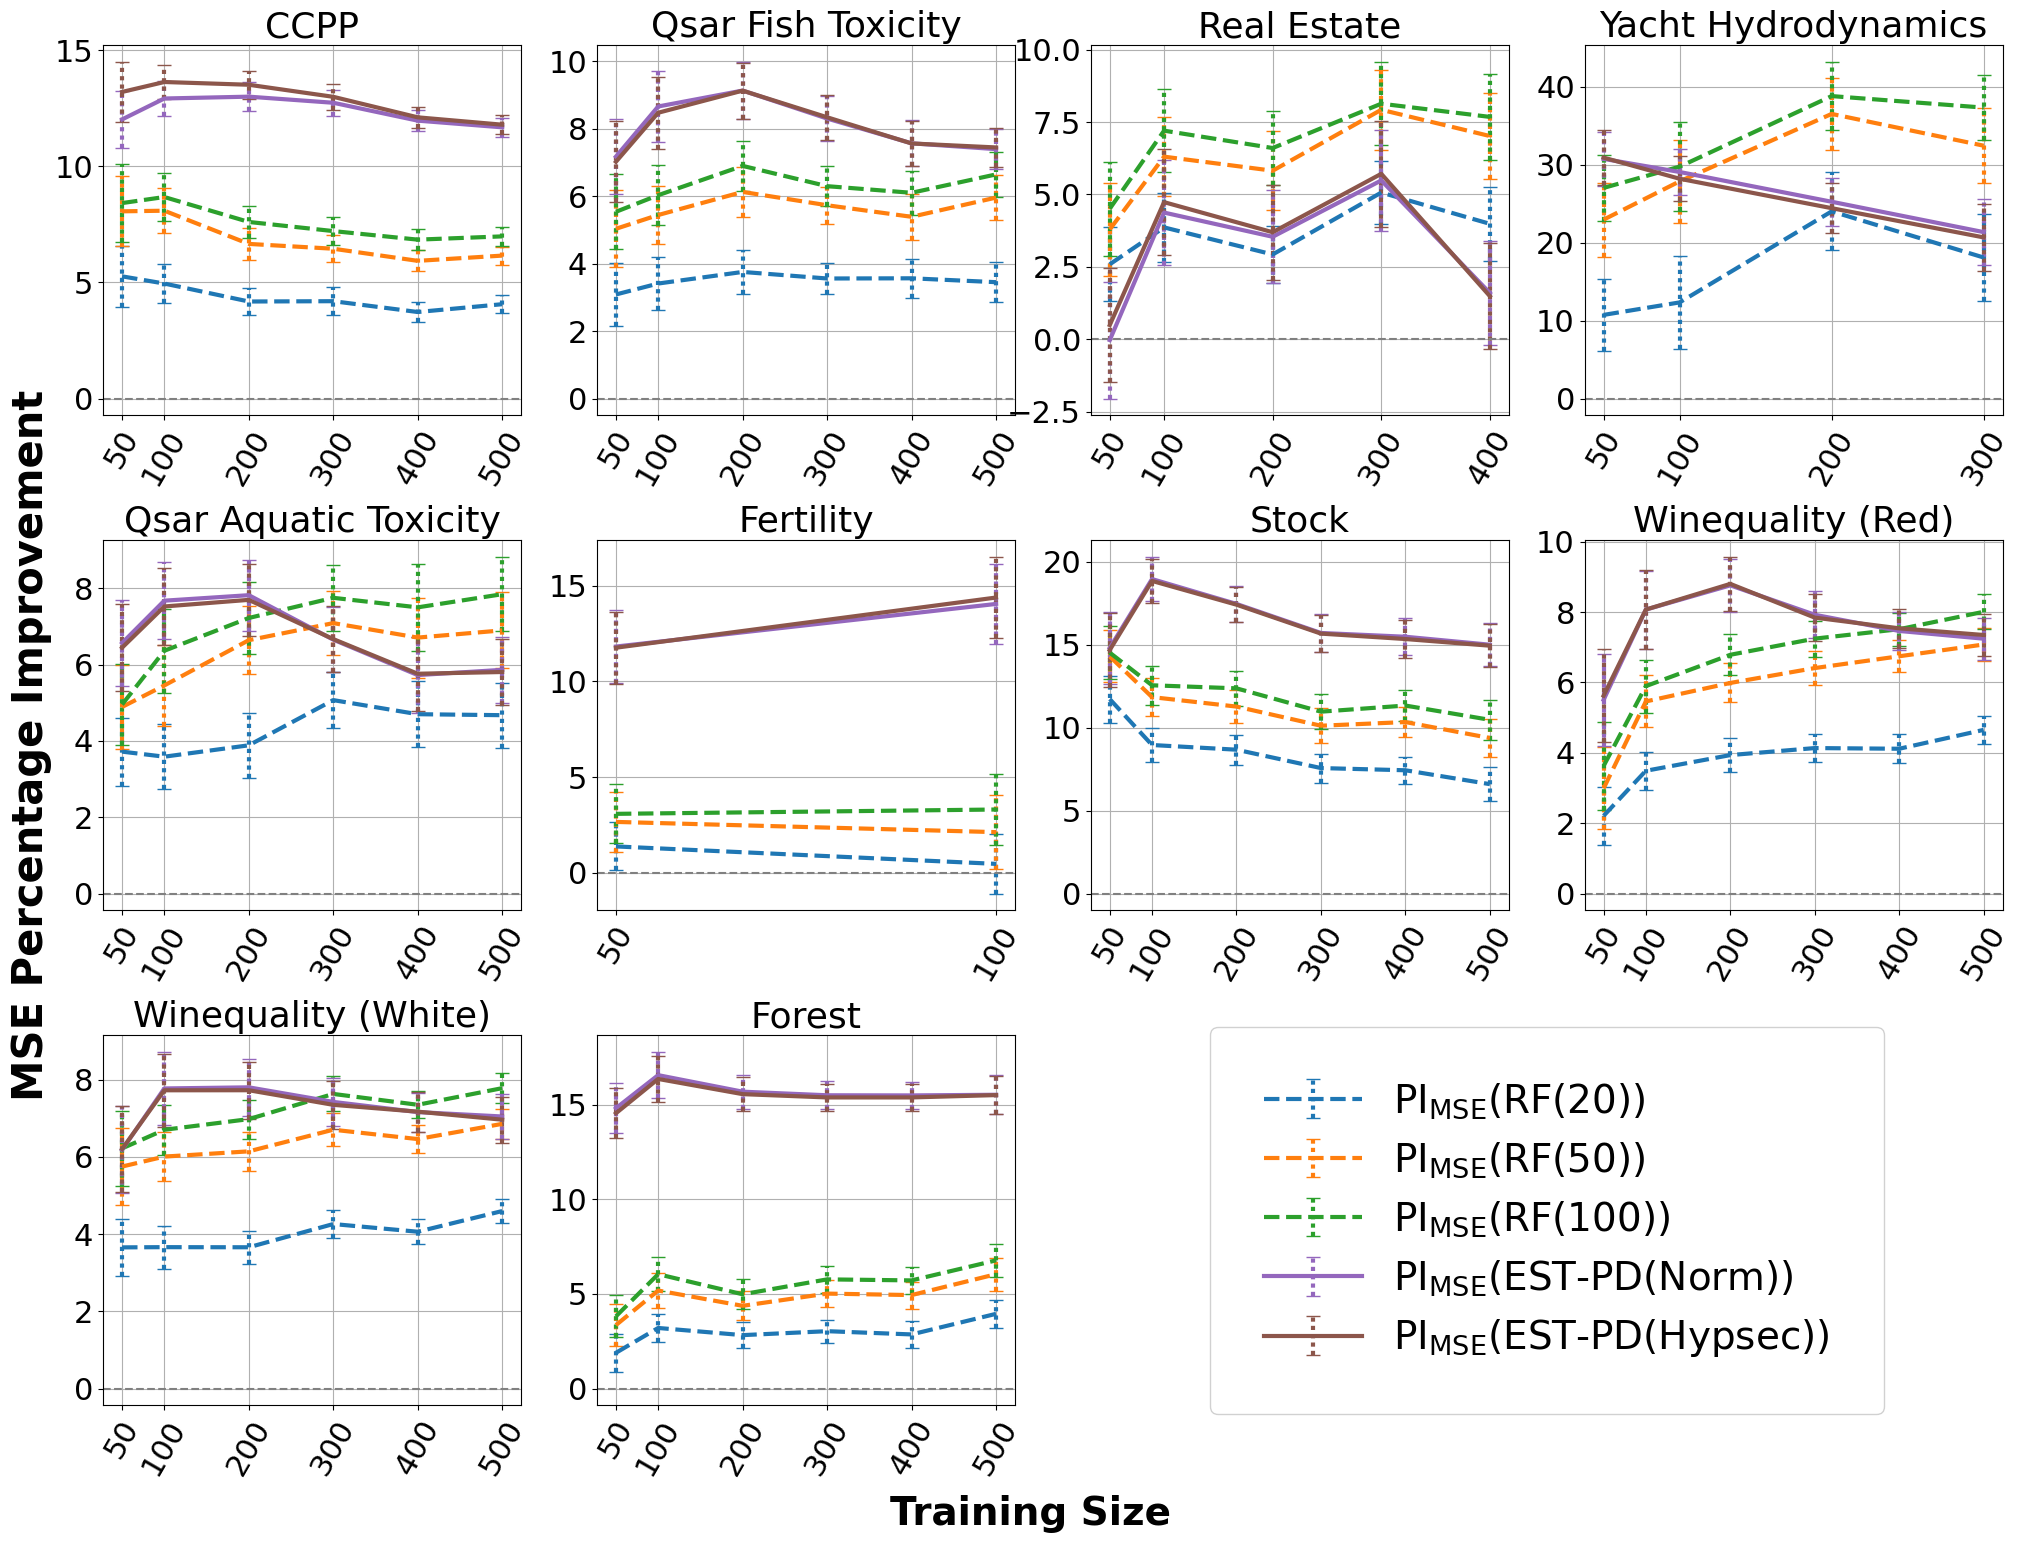

In [20]:
plot_metric_percentage_improve(pi_df,
                                   ncol=4,
                                   plot_type='errorbar',
                                   figure_size=(20, 15),
                                   show_legend=True,
                                   save_path='./figures/best_model_pi_new.pdf')

In [241]:
pi_df.columns

Index(['Data', 'N', 'P', 'n', 'r', 'RF(20)', 'RF(50)', 'RF(100)', 'GP',
       'SRF_EST_PD(Norm)', 'SRF_EST_PD(Hypsec)'],
      dtype='object')

In [22]:
print(f"EST-PD(Norm) greater than baseline (RF(10)): {round(len(pi_df[pi_df['SRF_EST_PD(Norm)']>0])/len(pi_df),2)*100}%")
print(f"EST-PD(Hypsec) greater than baseline (RF(10)): {round(len(pi_df[pi_df['SRF_EST_PD(Hypsec)']>0])/len(pi_df),2)*100}%")

EST-PD(Norm) greater than baseline (RF(10)): 93.0%
EST-PD(Hypsec) greater than baseline (RF(10)): 94.0%


In [28]:
print(f"EST-PD(Norm) greater than RF(20) cases {len(pi_df[pi_df['SRF_EST_PD(Norm)']>pi_df['RF(20)']])} percentage {round(len(pi_df[pi_df['SRF_EST_PD(Norm)']>pi_df['RF(20)']])/len(pi_df),4)*100}%")
print(f"EST-PD(Hypsec) greater than RF(20) cases {len(pi_df[pi_df['SRF_EST_PD(Hypsec)']>pi_df['RF(20)']])} percentage {round(len(pi_df[pi_df['SRF_EST_PD(Hypsec)']>pi_df['RF(20)']])/len(pi_df),4)*100}%")
print(f"EST-PD(Norm) greater than RF(50) cases {len(pi_df[pi_df['SRF_EST_PD(Norm)']>pi_df['RF(50)']])} percentage {round(len(pi_df[pi_df['SRF_EST_PD(Norm)']>pi_df['RF(50)']])/len(pi_df),4)*100}%")
print(f"EST-PD(Hypsec) greater than RF(50) cases {len(pi_df[pi_df['SRF_EST_PD(Hypsec)']>pi_df['RF(50)']])} percentage {round(len(pi_df[pi_df['SRF_EST_PD(Hypsec)']>pi_df['RF(50)']])/len(pi_df),4)*100}%")
print(f"EST-PD(Norm) greater than RF(100) cases {len(pi_df[pi_df['SRF_EST_PD(Norm)']>pi_df['RF(100)']])} percentage {round(len(pi_df[pi_df['SRF_EST_PD(Norm)']>pi_df['RF(100)']])/len(pi_df),4)*100}%")
print(f"EST-PD(Hypsec) greater than RF(100) cases {len(pi_df[pi_df['SRF_EST_PD(Hypsec)']>pi_df['RF(100)']])} percentage {round(len(pi_df[pi_df['SRF_EST_PD(Hypsec)']>pi_df['RF(100)']])/len(pi_df),4)*100}%")
print(f"EST-PD(Norm) greater than GP cases {len(pi_df[pi_df['SRF_EST_PD(Norm)']>pi_df['GP']])} percentage {round(len(pi_df[pi_df['SRF_EST_PD(Norm)']>pi_df['GP']])/len(pi_df),4)*100}%")
print(f"EST-PD(Hypsec) greater than GP cases {len(pi_df[pi_df['SRF_EST_PD(Hypsec)']>pi_df['GP']])} percentage {round(len(pi_df[pi_df['SRF_EST_PD(Hypsec)']>pi_df['GP']])/len(pi_df),4)*100}%")

EST-PD(Norm) greater than RF(20) cases 4269 percentage 80.55%
EST-PD(Hypsec) greater than RF(20) cases 4268 percentage 80.53%
EST-PD(Norm) greater than RF(50) cases 3659 percentage 69.04%
EST-PD(Hypsec) greater than RF(50) cases 3664 percentage 69.13%
EST-PD(Norm) greater than RF(100) cases 3374 percentage 63.660000000000004%
EST-PD(Hypsec) greater than RF(100) cases 3385 percentage 63.870000000000005%
EST-PD(Norm) greater than GP cases 4661 percentage 87.94%
EST-PD(Hypsec) greater than GP cases 4652 percentage 87.77000000000001%


In [20]:
combined_mse_df

,Data,N,P,n,r,RF(10),RF(20),RF(50),RF(100),GP,SRF_EST_PD(Norm),SRF_EST_PD(Hypsec)
0,Fertility,100,9,50,0,0.044909,0.045380,0.046300,0.043865,0.038578,0.035588,0.035576
1,Fertility,100,9,50,1,0.039270,0.035568,0.034324,0.035136,0.041738,0.035319,0.035108
2,Fertility,100,9,50,2,0.041473,0.039620,0.041042,0.039670,0.046084,0.036816,0.036961
3,Fertility,100,9,50,3,0.039350,0.042345,0.039342,0.039329,0.039149,0.036053,0.035912
4,Fertility,100,9,50,4,0.038044,0.035255,0.034489,0.034218,0.035312,0.033262,0.032896
...,...,...,...,...,...,...,...,...,...,...,...,...
5295,CCPP,9568,4,500,95,21.063966,20.376660,19.516723,19.339205,37.421178,18.319585,18.117337
5296,CCPP,9568,4,500,96,21.337937,21.012749,20.129322,19.987684,38.040156,18.658859,18.695136
5297,CCPP,9568,4,500,97,20.499778,19.931488,19.316219,19.063135,32.104660,18.447254,18.305758
5298,CCPP,9568,4,500,98,20.167187,19.498746,19.099909,19.036338,38.708539,18.633770,18.567238


In [27]:
model_cols = ['RF(10)', 'RF(20)', 'RF(50)', 'RF(100)', 'GP', 
              'SRF_EST_PD(Norm)', 'SRF_EST_PD(Hypsec)']

best_model_per_case = combined_mse_df[model_cols].idxmin(axis=1)


win_counts = best_model_per_case.value_counts()

total_cases = len(combined_mse_df)  
win_percentage = (win_counts / total_cases * 100).round(2)


summary = pd.DataFrame({
    'Win Count': win_counts,
    'Win Percentage (%)': win_percentage
})

print(summary)
print(f"\nTotal cases: {total_cases}")

print(f'EST-PD total wins: {win_counts["SRF_EST_PD(Norm)"] + win_counts["SRF_EST_PD(Hypsec)"]}')
print(f'EST-PD win percentage: {(win_counts["SRF_EST_PD(Norm)"] + win_counts["SRF_EST_PD(Hypsec)"]) / total_cases * 100}%')

                    Win Count  Win Percentage (%)
SRF_EST_PD(Hypsec)       1408               26.57
SRF_EST_PD(Norm)         1315               24.81
RF(100)                  1244               23.47
GP                        601               11.34
RF(50)                    481                9.08
RF(20)                    193                3.64
RF(10)                     58                1.09

Total cases: 5300
EST-PD total wins: 2723
EST-PD win percentage: 51.37735849056604%


## Appendix Tables

In [92]:
PIMSE_dataset_mean = pi_df.groupby(['Data','N','P','n']).mean().drop(columns=['r','cases']).reset_index()

In [108]:
PIMSE_dataset_mean = PIMSE_dataset_mean.sort_values(by=['P','Data','n'], ascending=True)

In [109]:
PIMSE_dataset_mean

,Data,N,P,n,RF(20),RF(50),RF(100),GP,EST-PD(Norm),EST-PD(Hypsec)
0,CCPP,9568,4,50,5.262190,8.064036,8.419888,-48.311806,12.024059,13.206640
1,CCPP,9568,4,100,4.952779,8.090350,8.679800,-66.005043,12.924679,13.635084
2,CCPP,9568,4,200,4.178911,6.660117,7.606281,-72.130863,13.003511,13.516542
3,CCPP,9568,4,300,4.192638,6.452609,7.212738,-85.717329,12.740718,12.997146
4,CCPP,9568,4,400,3.726642,5.930657,6.844335,-96.627530,11.970218,12.113124
5,CCPP,9568,4,500,4.062894,6.156225,6.984655,-90.062081,11.682314,11.796116
20,Qsar Fish Toxicity,908,6,50,3.086531,5.035364,5.539543,-15.481019,7.177493,7.023922
21,Qsar Fish Toxicity,908,6,100,3.411161,5.443953,6.031955,-22.027710,8.664148,8.478349
22,Qsar Fish Toxicity,908,6,200,3.755363,6.129563,6.901777,-22.873080,9.136693,9.134549
23,Qsar Fish Toxicity,908,6,300,3.560659,5.734057,6.300248,-19.905197,8.306229,8.344162


In [110]:
PIMSE_dataset_mean.to_csv('./metrics/PIMSE_dataset_mean.csv',index=False)

In [111]:
MSE_dataset_mean = combined_mse_df.groupby(['Data','N','P','n']).mean().drop(columns=['r']).reset_index()
MSE_dataset_mean = MSE_dataset_mean.sort_values(by=['P','Data','n'], ascending=True)

In [112]:
MSE_dataset_mean.to_csv('./metrics/MSE_dataset_mean.csv',index=False)

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations

# Level 2: 在r维度先average
df_level2 = pi_df.groupby(['Data', 'n'])[
    ['RF(20)', 'RF(50)', 'RF(100)', 'GP', 'EST-PD(Norm)', 'EST-PD(Hypsec)']
].mean().reset_index()

# Level 3: 在r和n维度都average
df_level3 = pi_df.groupby(['Data'])[
    ['RF(20)', 'RF(50)', 'RF(100)', 'GP', 'EST-PD(Norm)', 'EST-PD(Hypsec)']
].mean().reset_index()

# Friedman test at each level
def run_friedman(df, methods):
    data = [df[m].values for m in methods]
    stat, p = friedmanchisquare(*data)
    return stat, p, len(df)

methods = ['RF(20)', 'RF(50)', 'RF(100)', 'GP', 'EST-PD(Norm)', 'EST-PD(Hypsec)']

print("Level 2 (avg over r, block=(dataset,n)):")
print(run_friedman(df_level2, methods))

print("Level 3 (avg over r and n, block=dataset):")
print(run_friedman(df_level3, methods))

# 关键的pairwise test: SRF vs RF(100) at level 3
# 用Wilcoxon signed-rank会比Nemenyi更power
print("\nPairwise Wilcoxon at Level 3:")
for m1, m2 in [('EST-PD(Norm)', 'RF(100)'), 
                ('EST-PD(Hypsec)', 'RF(100)'),
                ('EST-PD(Norm)', 'EST-PD(Hypsec)')]:
    stat, p = wilcoxon(df_level3[m1], df_level3[m2])
    print(f"{m1} vs {m2}: stat={stat:.3f}, p={p:.4f}")

Level 2 (avg over r, block=(dataset,n)):
(np.float64(164.00808625336936), np.float64(1.3839894906233881e-33), 53)
Level 3 (avg over r and n, block=dataset):
(np.float64(29.714285714285694), np.float64(1.6786529640926665e-05), 10)

Pairwise Wilcoxon at Level 3:
EST-PD(Norm) vs RF(100): stat=15.000, p=0.2324
EST-PD(Hypsec) vs RF(100): stat=15.000, p=0.2324
EST-PD(Norm) vs EST-PD(Hypsec): stat=25.000, p=0.8457
